In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def loss_calc(org_str, gen_str):
    
    try:

        x_lines = [x for x in org_str.split("\n") if len(x) > 0]
        x_lengths = [float(x) for x in x_lines[0].split(" ")]
        x_angles = [float(x) for x in x_lines[1].split(" ")]
        x_species = [x for x in x_lines[2::2]]
        x_coords = [[float(y) for y in x.split(" ")] for x in x_lines[3::2]]

        y_lines = [x for x in gen_str.split("\n") if len(x) > 0]
        y_lengths = [float(x) for x in y_lines[0].split(" ")]
        y_angles = [float(x) for x in y_lines[1].split(" ")]
        y_species = [x for x in y_lines[2::2]]
        y_coords = [[float(y) for y in x.split(" ")] for x in y_lines[3::2]]
    except Exception as e:
        #print(e)
        return 0, 0, 0, 0

    # Mean Absolute Error (MAE)
    try:
        lenght_loss = np.mean(np.abs((np.array(x_lengths) - np.array(y_lengths))))
        angle_loss = np.mean(np.abs((np.array(x_angles) - np.array(y_angles))))
        coord_loss = np.mean(np.abs((np.array(x_coords) - np.array(y_coords))))
        return lenght_loss, angle_loss, coord_loss, 1
    except Exception as e:
        #print(e)
        return 0, 0, 0, 0
    

def get_lenght(org_str, gen_str):

    try:
        x_lines = [x for x in org_str.split("\n") if len(x) > 0]
        x_lengths = [float(x) for x in x_lines[0].split(" ")]

        y_lines = [x for x in gen_str.split("\n") if len(x) > 0]
        y_lengths = [float(x) for x in y_lines[0].split(" ")]
        
        return x_lengths, y_lengths, 1


    except Exception as e:
        return 0, 0, 0


In [3]:
# Read the files
fourbit_models = [
        "unsloth/tinyllama-chat", #X
        "unsloth/mistral-7b-bnb-4bit", #X
        "unsloth/gemma-7b-bnb-4bit", #X
        "unsloth/llama-3-8b-bnb-4bit", #X 
]  # More models at https://huggingface.co/unsloth

# TC_SUPERCON

In [ ]:
for idx, name in enumerate(fourbit_models):

        #Read the model
        fourbit_model = fourbit_models[idx]
        path = f"./0_gen_tc_supercon/{fourbit_model.split('/')[1]}_generated_samples_relaxed.csv"
        df = pd.read_csv(path)
        print("********", name)

        angle_loss_ = []
        lenght_loss_ = []
        coord_loss_ = []

        for jdx, nname in df.iterrows():

                xx = df.iloc[jdx]["response"]
                yy = df.iloc[jdx]["gen_material_str"]

                lenght_loss, angle_loss, coord_loss, correct = loss_calc(xx, yy)
                if correct:
                        angle_loss_.append(angle_loss)
                        lenght_loss_.append(lenght_loss)
                        coord_loss_.append(coord_loss)

        print("len", len(df), "calculated", len(coord_loss_),  "coord_loss_", np.mean(coord_loss_), "lenght_loss_", np.mean(lenght_loss_), "angle_loss_", np.mean(angle_loss_))

******** unsloth/tinyllama-chat
len 106 calculated 74 coord_loss_ 0.22686674174174173 lenght_loss_ 0.48603603603603607 angle_loss_ 8.725225225225227
******** unsloth/mistral-7b-bnb-4bit
len 106 calculated 92 coord_loss_ 0.18380210489993096 lenght_loss_ 0.4032608695652174 angle_loss_ 6.021739130434782
******** unsloth/gemma-7b-bnb-4bit
len 106 calculated 87 coord_loss_ 0.15475725232621787 lenght_loss_ 0.3754789272030651 angle_loss_ 5.042145593869732
******** unsloth/llama-3-8b-bnb-4bit
len 106 calculated 85 coord_loss_ 0.20369271708683473 lenght_loss_ 0.42274509803921567 angle_loss_ 7.447058823529413


******** unsloth/tinyllama-chat


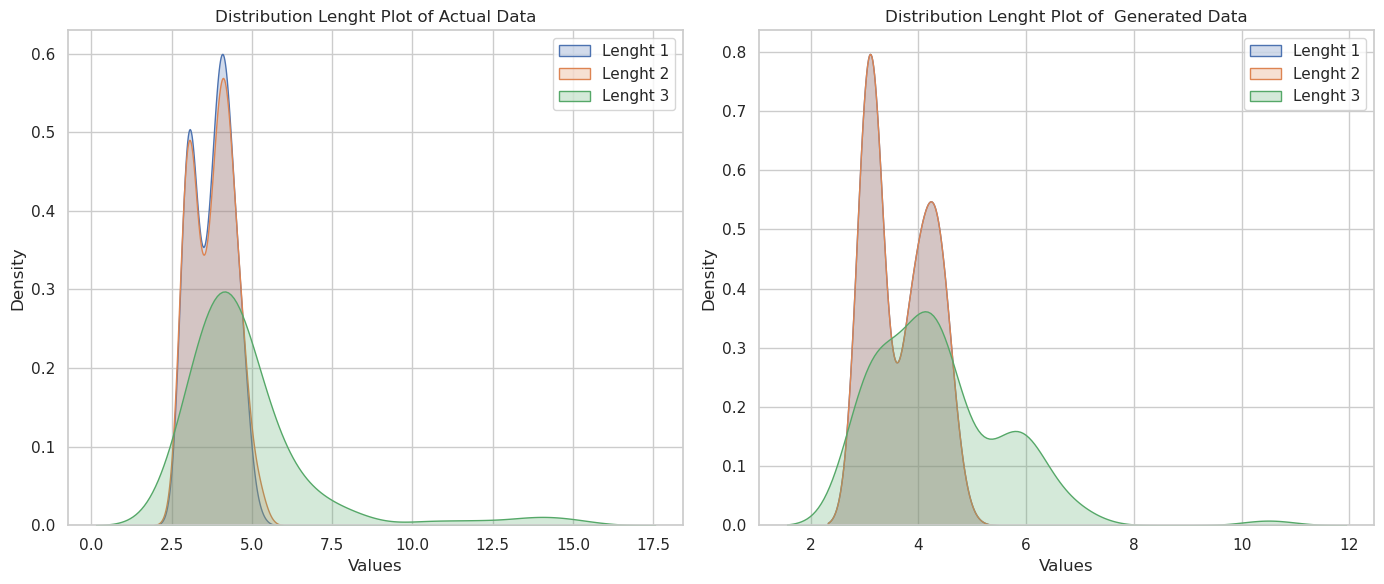

******** unsloth/mistral-7b-bnb-4bit


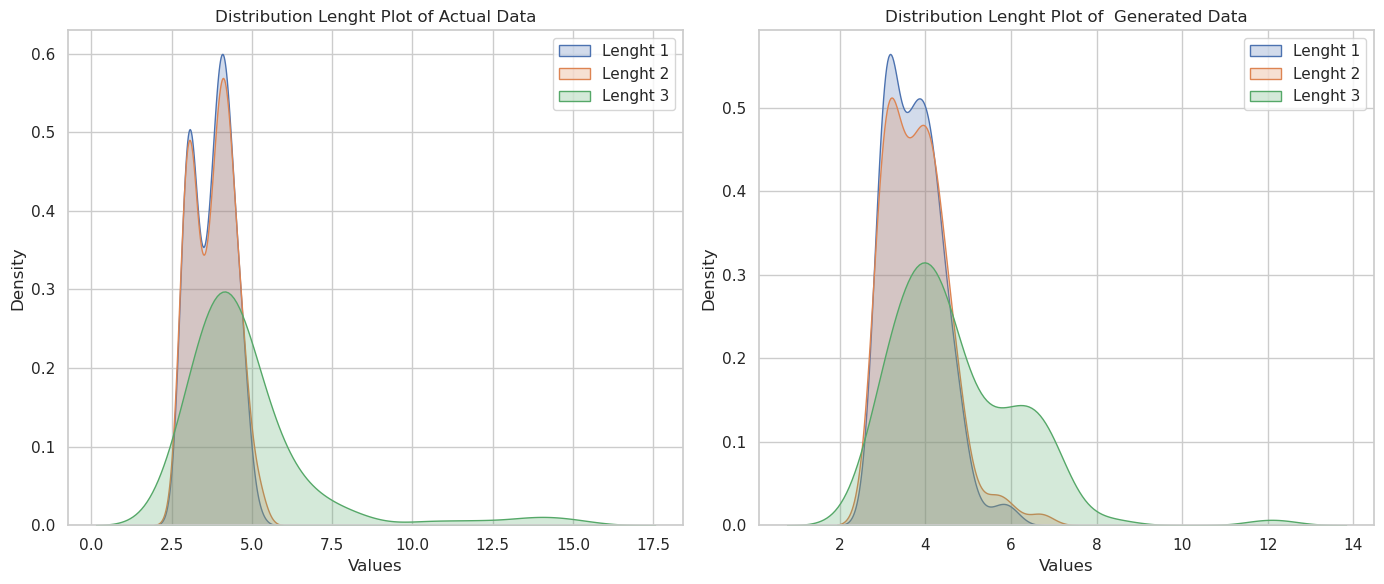

******** unsloth/gemma-7b-bnb-4bit


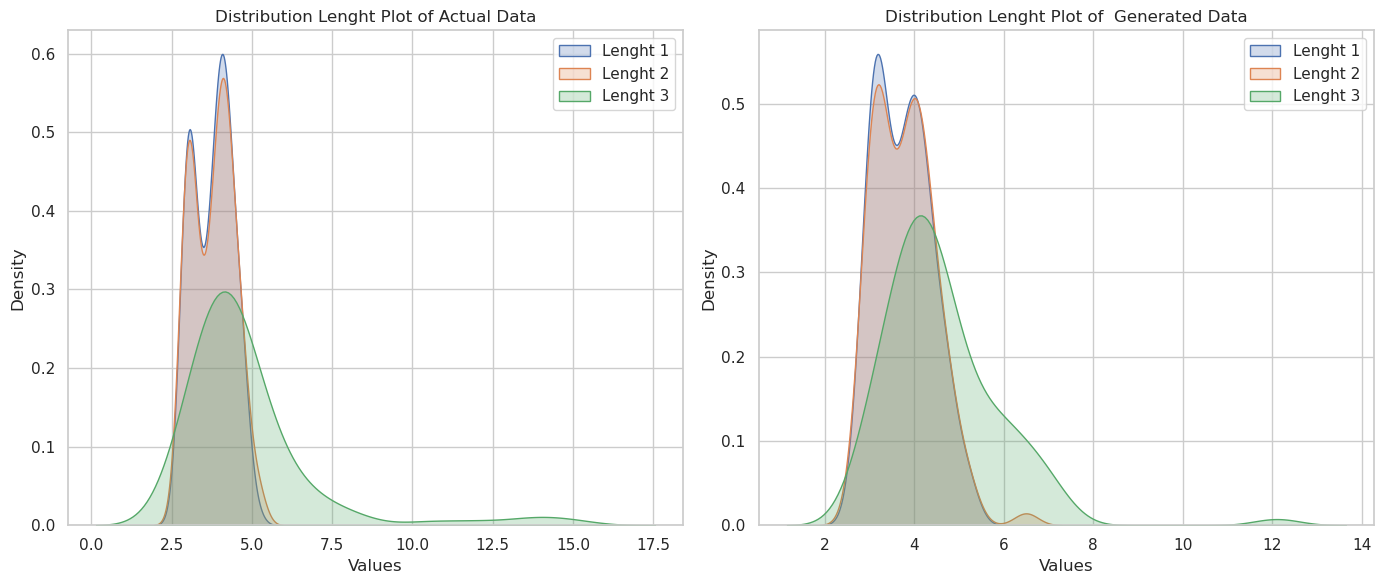

******** unsloth/llama-3-8b-bnb-4bit


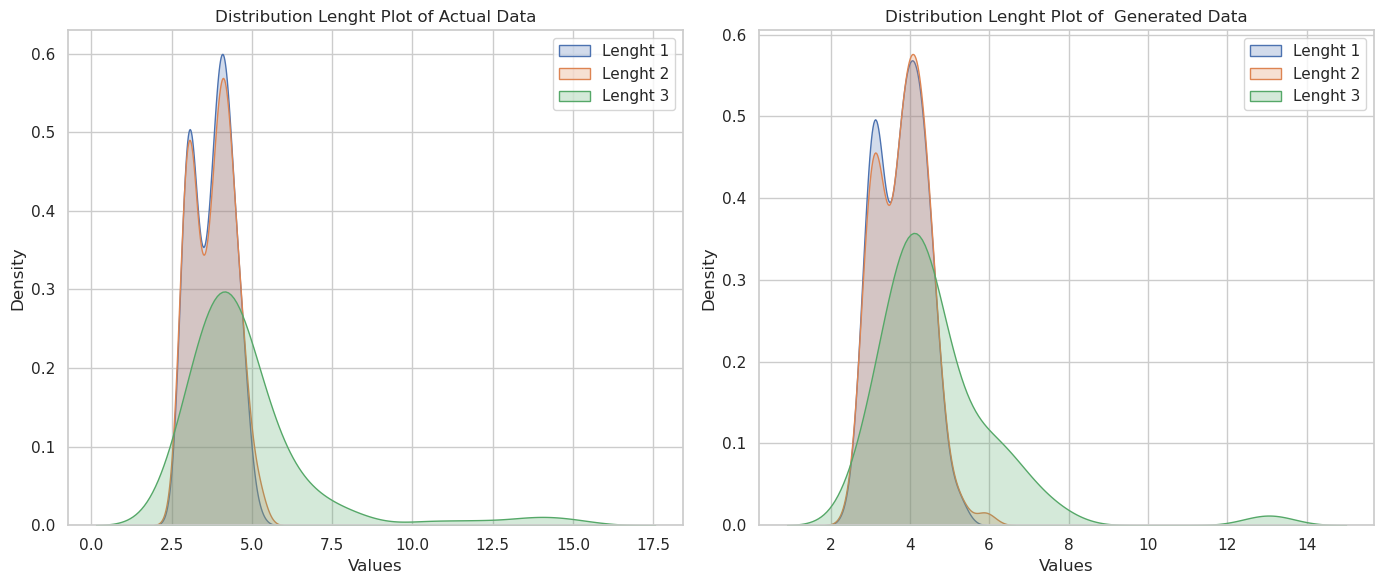

In [ ]:
for idx, name in enumerate(fourbit_models):

        #Read the model
        fourbit_model = fourbit_models[idx]
        path = f"./0_gen_tc_supercon/{fourbit_model.split('/')[1]}_generated_samples_relaxed.csv"
        df = pd.read_csv(path)
        print("********", name)

        lenght_x = []
        lenght_y = []

        for jdx, nname in df.iterrows():

                xx = df.iloc[jdx]["response"]
                yy = df.iloc[jdx]["gen_material_str"]

                lenghtx, lenghty, correct = get_lenght(xx, yy)
                if correct:
                        lenght_x.append(lenghtx)
                        lenght_y.append(lenghty)

      
        sns.set(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Plot generated data
        for i in range(np.array(lenght_x).shape[1]):
                sns.kdeplot(np.array(lenght_x)[:, i], label=f'Lenght {i+1}', fill=True, ax=axes[0])
        axes[0].legend()
        #axes[0].set_title("Distribution Lenght Plot of Actual Data")
        #axes[0].set_xlabel("Values")
        #axes[0].set_ylabel("Density")

        # Plot actual data
        for i in range(np.array(lenght_y).shape[1]):
                sns.kdeplot(np.array(lenght_y)[:, i], label=f'Lenght {i+1}', fill=True, ax=axes[1])
        axes[1].legend()
        #axes[1].set_title("Distribution Lenght Plot of  Generated Data")
        #axes[1].set_xlabel("Values")
        #axes[1].set_ylabel("Density")

        plt.tight_layout()
        plt.show()


# OPT88

In [87]:
for idx, name in enumerate(fourbit_models):

        #Read the model
        fourbit_model = fourbit_models[idx]
        path = f"./1_gen_optb88vdw_bandgap/{fourbit_model.split('/')[1]}_generated_samples_relaxed.csv"
        df = pd.read_csv(path)
        print("********", name)

        angle_loss_ = []
        lenght_loss_ = []
        coord_loss_ = []

        for jdx, nname in df.iterrows():

                xx = df.iloc[jdx]["response"]
                yy = df.iloc[jdx]["gen_material_str"]

                lenght_loss, angle_loss, coord_loss, correct = loss_calc(xx, yy)
                if correct:
                        angle_loss_.append(angle_loss)
                        lenght_loss_.append(lenght_loss)
                        coord_loss_.append(coord_loss)

        print("len", len(df), "calculated", len(coord_loss_),  "coord_loss_", np.mean(coord_loss_), "lenght_loss_", np.mean(lenght_loss_), "angle_loss_", np.mean(angle_loss_))

******** unsloth/tinyllama-chat
len 2307 calculated 1314 coord_loss_ 0.2721851184002416 lenght_loss_ 0.8619989852866564 angle_loss_ 12.144563673262304
******** unsloth/mistral-7b-bnb-4bit
len 2307 calculated 1529 coord_loss_ 0.24374431365247617 lenght_loss_ 0.7416394157401351 angle_loss_ 9.427556136908654
******** unsloth/gemma-7b-bnb-4bit
len 2307 calculated 1490 coord_loss_ 0.2475304132158634 lenght_loss_ 0.765950782997763 angle_loss_ 10.3668903803132
******** unsloth/llama-3-8b-bnb-4bit
len 2307 calculated 1458 coord_loss_ 0.2479728571650861 lenght_loss_ 0.7346227709190671 angle_loss_ 9.804069501600365


******** unsloth/tinyllama-chat


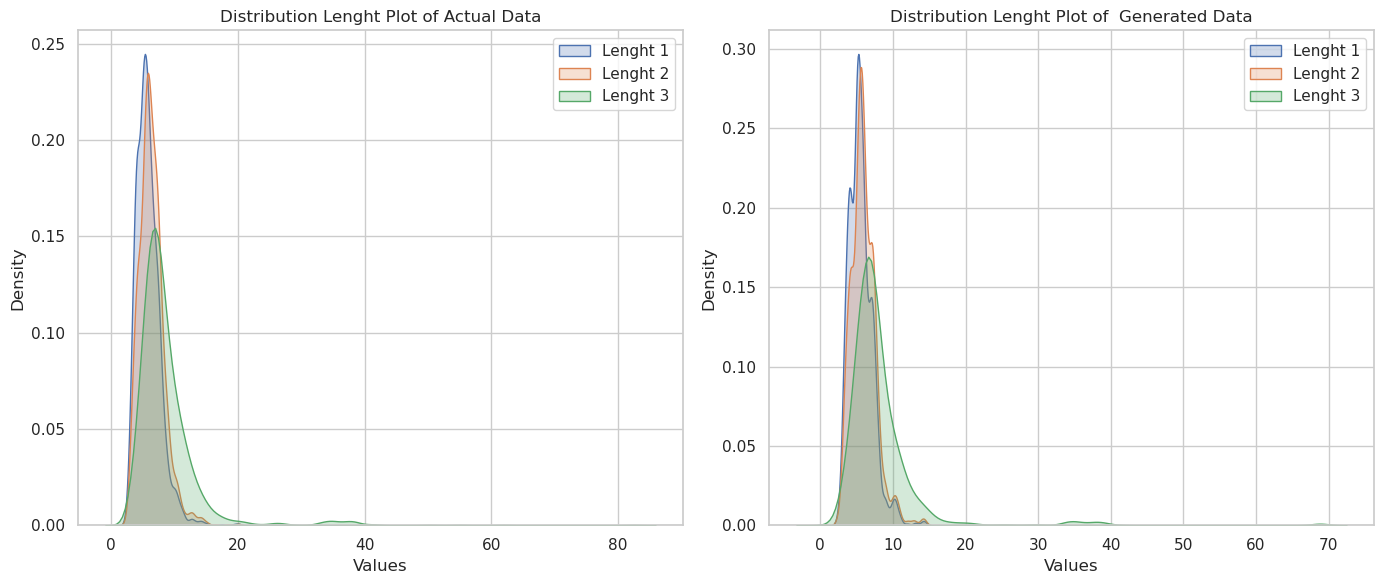

******** unsloth/mistral-7b-bnb-4bit


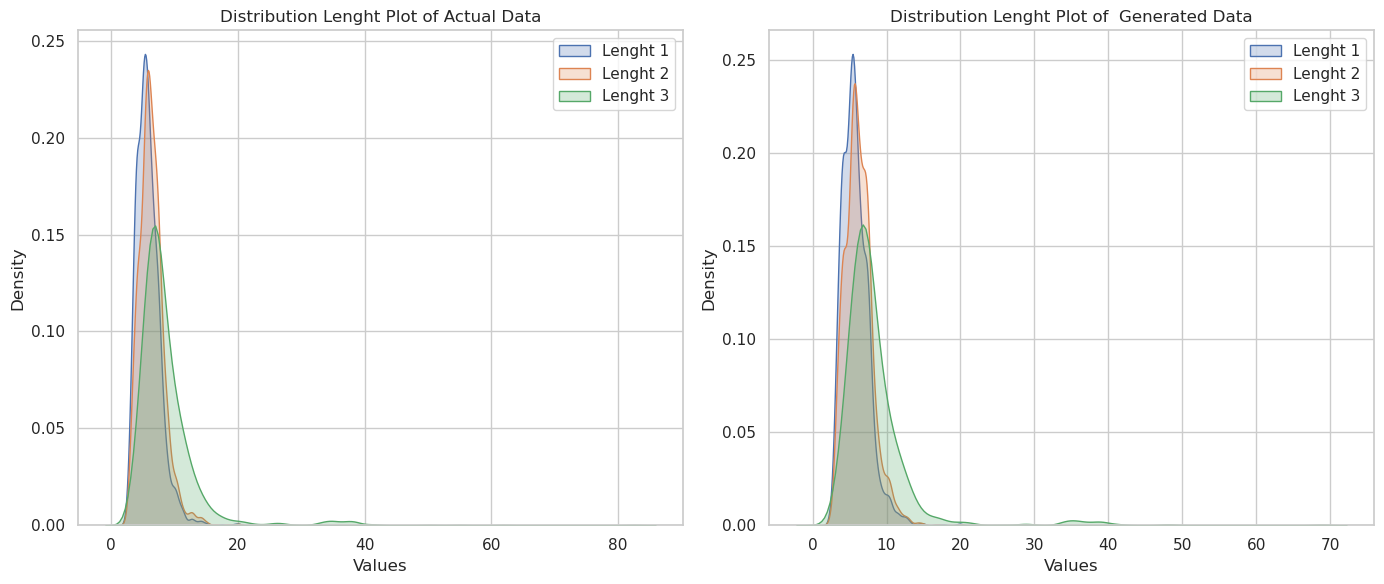

******** unsloth/gemma-7b-bnb-4bit


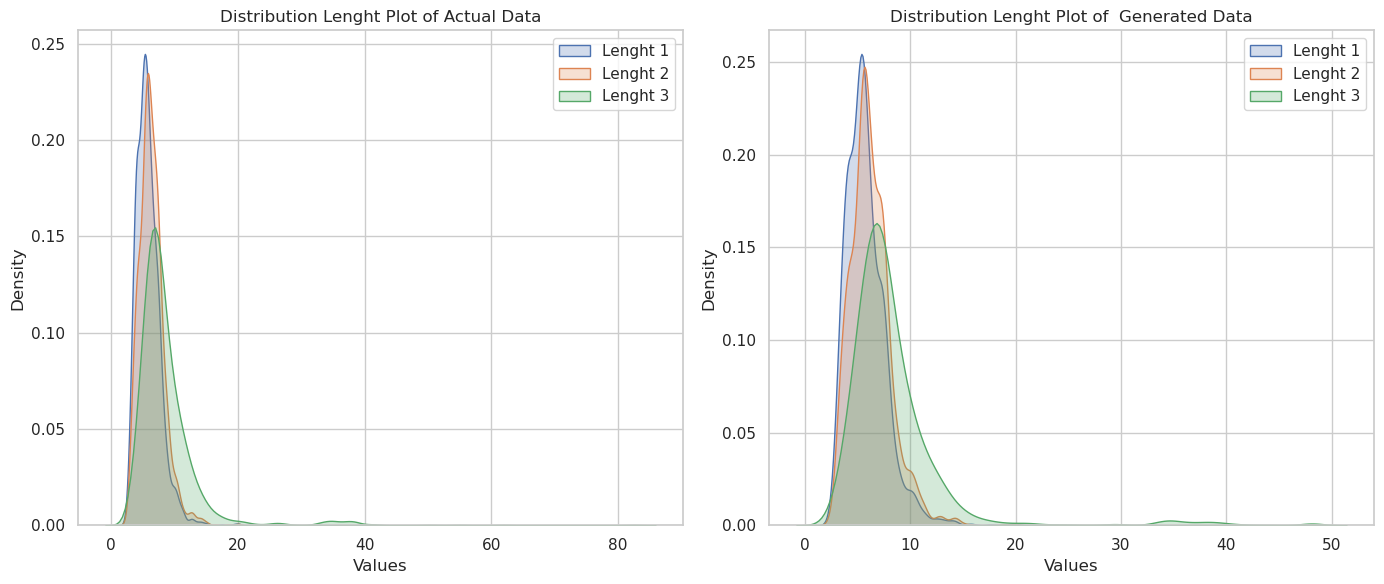

******** unsloth/llama-3-8b-bnb-4bit


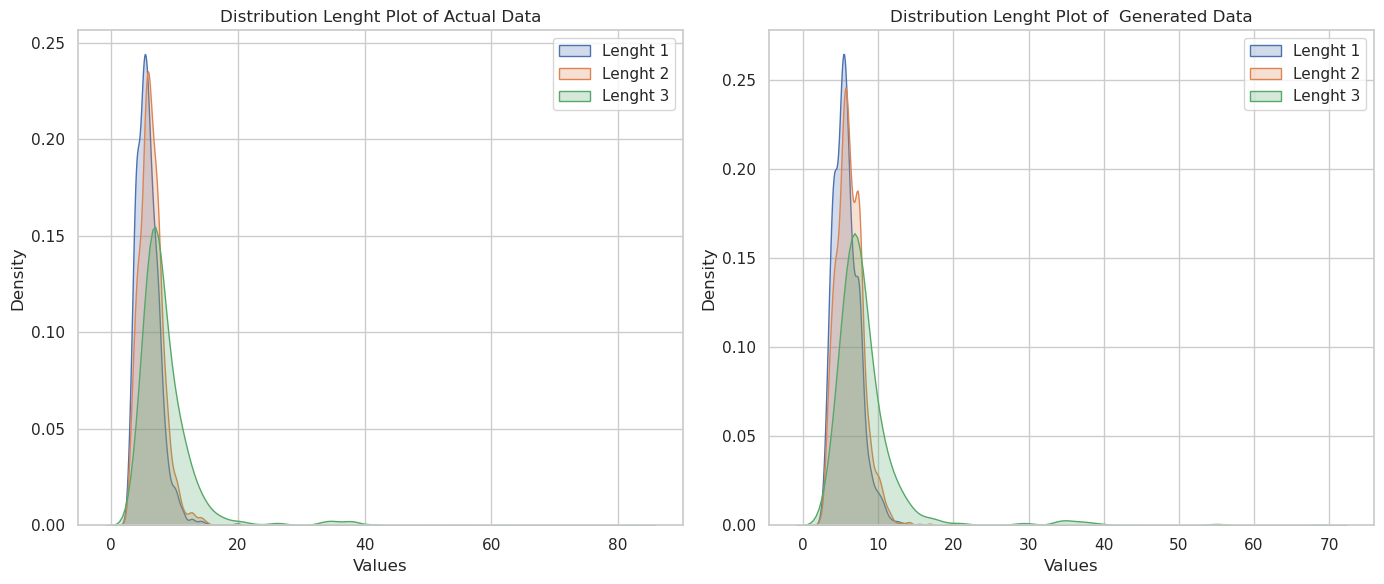

In [20]:
for idx, name in enumerate(fourbit_models):

        #Read the model
        fourbit_model = fourbit_models[idx]
        path = f"./1_gen_optb88vdw_bandgap/{fourbit_model.split('/')[1]}_generated_samples_relaxed.csv"
        df = pd.read_csv(path)
        print("********", name)

        lenght_x = []
        lenght_y = []

        for jdx, nname in df.iterrows():

                xx = df.iloc[jdx]["response"]
                yy = df.iloc[jdx]["gen_material_str"]

                lenghtx, lenghty, correct = get_lenght(xx, yy)
                if correct:
                        lenght_x.append(lenghtx)
                        lenght_y.append(lenghty)

      
        sns.set(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Plot generated data
        for i in range(np.array(lenght_x).shape[1]):
                sns.kdeplot(np.array(lenght_x)[:, i], label=f'Lenght {i+1}', fill=True, ax=axes[0])
        axes[0].legend()
        axes[0].set_title("Distribution Lenght Plot of Actual Data")
        axes[0].set_xlabel("Values")
        axes[0].set_ylabel("Density")

        # Plot actual data
        for i in range(np.array(lenght_y).shape[1]):
                sns.kdeplot(np.array(lenght_y)[:, i], label=f'Lenght {i+1}', fill=True, ax=axes[1])
        axes[1].legend()
        axes[1].set_title("Distribution Lenght Plot of  Generated Data")
        axes[1].set_xlabel("Values")
        axes[1].set_ylabel("Density")

        plt.tight_layout()
        plt.show()


# MBJ BADNGAP

In [89]:
for idx, name in enumerate(fourbit_models):

        #Read the model
        fourbit_model = fourbit_models[idx]
        path = f"./2_gen_mbj_bandgap/{fourbit_model.split('/')[1]}_generated_samples_relaxed.csv"
        df = pd.read_csv(path)
        print("********", name)

        angle_loss_ = []
        lenght_loss_ = []
        coord_loss_ = []

        for jdx, nname in df.iterrows():

                xx = df.iloc[jdx]["response"]
                yy = df.iloc[jdx]["gen_material_str"]

                lenght_loss, angle_loss, coord_loss, correct = loss_calc(xx, yy)
                if correct:
                        angle_loss_.append(angle_loss)
                        lenght_loss_.append(lenght_loss)
                        coord_loss_.append(coord_loss)

        print("len", len(df), "calculated", len(coord_loss_),  "coord_loss_", np.mean(coord_loss_), "lenght_loss_", np.mean(lenght_loss_), "angle_loss_", np.mean(angle_loss_))

******** unsloth/tinyllama-chat
len 1981 calculated 1369 coord_loss_ 0.2224996405145048 lenght_loss_ 0.5945215485756026 angle_loss_ 11.248940832724617
******** unsloth/mistral-7b-bnb-4bit
len 1981 calculated 1495 coord_loss_ 0.21068953820168962 lenght_loss_ 0.5911304347826087 angle_loss_ 10.52263099219621
******** unsloth/gemma-7b-bnb-4bit
len 1981 calculated 1479 coord_loss_ 0.2119256395245571 lenght_loss_ 0.5938922695514987 angle_loss_ 10.626549470362859
******** unsloth/llama-3-8b-bnb-4bit
len 1981 calculated 1474 coord_loss_ 0.21527476597988926 lenght_loss_ 0.5973541383989145 angle_loss_ 10.738127544097694


******** unsloth/tinyllama-chat


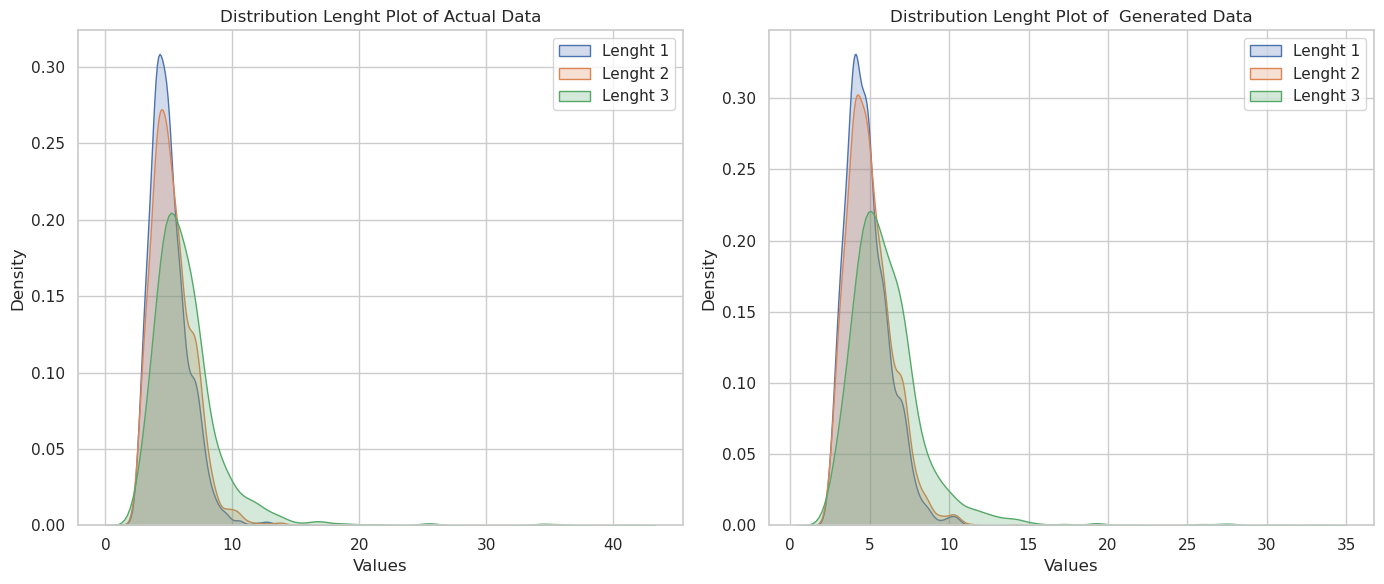

******** unsloth/mistral-7b-bnb-4bit


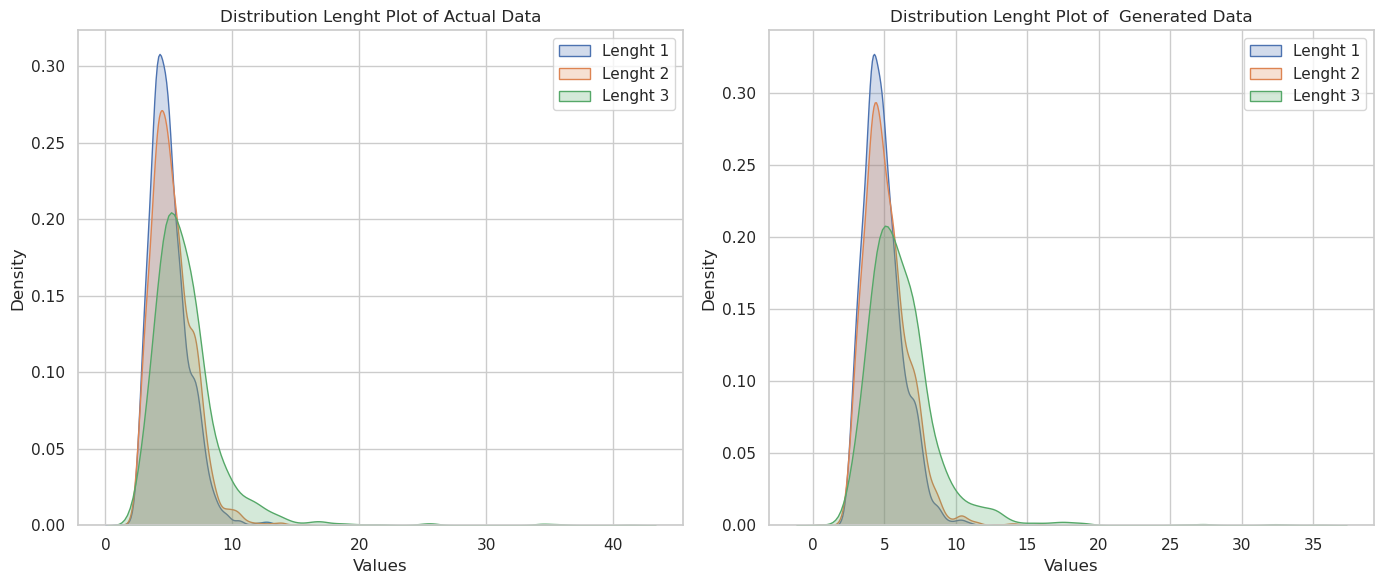

******** unsloth/gemma-7b-bnb-4bit


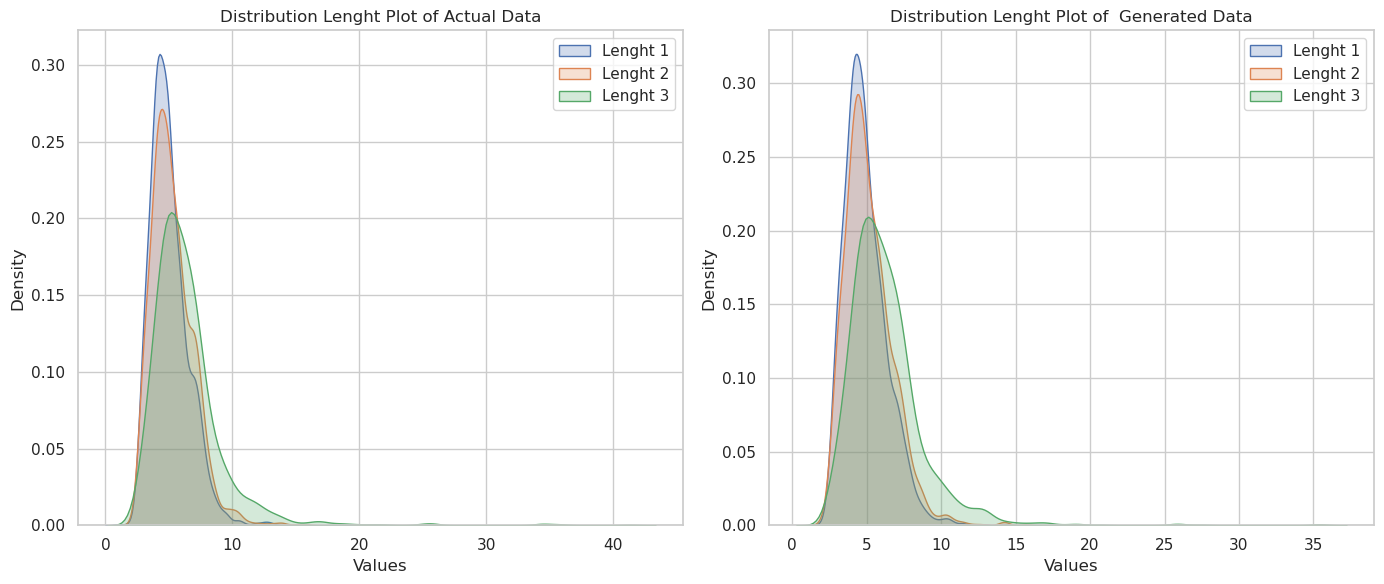

******** unsloth/llama-3-8b-bnb-4bit


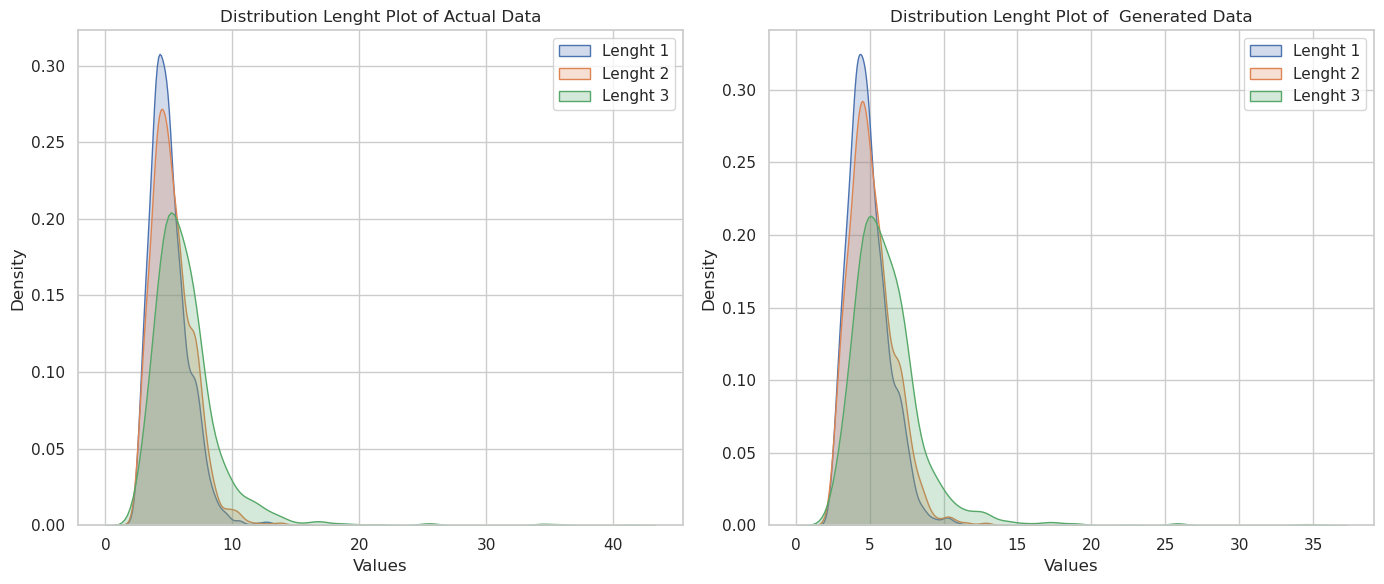

In [21]:
for idx, name in enumerate(fourbit_models):

        #Read the model
        fourbit_model = fourbit_models[idx]
        path = f"./2_gen_mbj_bandgap/{fourbit_model.split('/')[1]}_generated_samples_relaxed.csv"
        df = pd.read_csv(path)
        print("********", name)

        lenght_x = []
        lenght_y = []

        for jdx, nname in df.iterrows():

                xx = df.iloc[jdx]["response"]
                yy = df.iloc[jdx]["gen_material_str"]

                lenghtx, lenghty, correct = get_lenght(xx, yy)
                if correct:
                        lenght_x.append(lenghtx)
                        lenght_y.append(lenghty)

      
        sns.set(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Plot generated data
        for i in range(np.array(lenght_x).shape[1]):
                sns.kdeplot(np.array(lenght_x)[:, i], label=f'Lenght {i+1}', fill=True, ax=axes[0])
        axes[0].legend()
        axes[0].set_title("Distribution Lenght Plot of Actual Data")
        axes[0].set_xlabel("Values")
        axes[0].set_ylabel("Density")

        # Plot actual data
        for i in range(np.array(lenght_y).shape[1]):
                sns.kdeplot(np.array(lenght_y)[:, i], label=f'Lenght {i+1}', fill=True, ax=axes[1])
        axes[1].legend()
        axes[1].set_title("Distribution Lenght Plot of  Generated Data")
        axes[1].set_xlabel("Values")
        axes[1].set_ylabel("Density")

        plt.tight_layout()
        plt.show()
